## **Historical Data**

[Yahoo Finance](http://finance.yahoo.com/)

### **Imports**



In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime

In [2]:
from pylab import plt
# Check available styles using: print(plt.style.available)
plt.style.use('seaborn-v0_8-colorblind')
%config InlineBackend.figure_format = 'svg'

In [3]:
# plt.style.available

### **Aspect Partners Risk Parity**

|Ticker|Name|Allocation|
|---|---|---|
|TLT|iShares 20+ Year Treasury Bond ETF|5.00%|
|IEFA|iShares Core MSCI EAFE ETF|11.00%|
PDBC|Invesco Optm Yd Dvrs Cdty Stra No K1 ETF|10.00%
IAGG|iShares Core International Aggt Bd ETF|5.00%
IAU|iShares Gold Trust|10.00%
DSMC|Distillate Small/Mid Cash Flow ETF|6.00%
RSSB|Return Stacked Global Stocks&Bonds ETF|10.00%
ASFYX|Virtus AlphaSimplex Mgd Futs Strat I|10.00%
APDFX|Artisan High Income Advisor|5.00%
QMHIX|AQR Managed Futures Strategy HV I|10.00%
^CASHUS|U.S. 3-Month Treasury Bill Rate|1.00%
GQGIX|GQG Partners Emerging Markets EquityInst|6.00%
SPY|State Street SPDR S&P 500 ETF|11.00%

### **SPY + Long Vol**

|Ticker|Name|Allocation|
|---|---|---|
|SPY|State Street SPDR S&P 500 ETF|60.00%|
|CAOS|Alpha Arquitect Tail Risk ETF|40.00%|

### **SPY + Long Bond**

|Ticker|Name|Allocation|
|---|---|---|
|SPY|State Street SPDR S&P 500 ETF|60.00%|
|AGG|IShares Core US Aggregate Bond ETF|40.00%|

In [3]:
tickers_AP = ['TLT', 'IEFA', 'PDBC', 'IAGG', 'IAU', 'DSMC', 'RSSB', 'ASFYX',
           'APDFX', 'QMHIX', 'CASH', 'GQGIX', 'SPY']
tickers_SPY_LV = ['SPY', 'CAOS']
tickers_SPY_LB = ['SPY', 'AGG']
tickers_GAL = ['GAL'] # State Street Global Allocation
tickers = [tickers_AP, tickers_SPY_LV, tickers_SPY_LB, tickers_GAL]
start_date = '2024-1-1'
end_date = datetime.now()
portfolio_data = []
for i, val in enumerate(tickers):
    portfolio_data.append(yf.download(val, start = start_date,
                             end = end_date)['Close'])
    print(portfolio_data[i].tail(10))

[*********************100%***********************]  13 of 13 completed
[*********************100%***********************]  2 of 2 completed

Ticker      APDFX  ASFYX       CASH       DSMC      GQGIX       IAGG  \
Date                                                                   
2026-02-13   9.16   8.14  92.449997  38.368000  19.160000  50.520000   
2026-02-17   9.16   8.12  93.370003  38.183998  19.280001  50.580002   
2026-02-18   9.16   8.18  93.150002  38.443001  19.360001  50.560001   
2026-02-19   9.16   8.17  94.519997  38.459999  19.280001  50.599998   
2026-02-20   9.16   8.24  95.709999  38.570000  19.540001  50.660000   
2026-02-23   9.15   8.21  92.800003  37.630001  19.459999  50.720001   
2026-02-24   9.13   8.25  92.849998  37.889999  19.580000  50.720001   
2026-02-25   9.14   8.35  94.269997  37.880001  19.639999  50.689999   
2026-02-26   9.12   8.34  94.879997  38.150002  19.540001  50.740002   
2026-02-27   9.11   8.34  90.790001  37.787998  19.379999  50.860001   

Ticker            IAU       IEFA   PDBC  QMHIX       RSSB         SPY  \
Date                                                          


[*********************100%***********************]  2 of 2 completed


Ticker             AGG         SPY
Date                              
2026-02-13  100.989998  681.750000
2026-02-17  101.000000  682.849976
2026-02-18  100.860001  686.289978
2026-02-19  100.879997  684.479980
2026-02-20  100.900002  689.429993
2026-02-23  101.099998  682.390015
2026-02-24  101.089996  687.349976
2026-02-25  101.040001  693.150024
2026-02-26  101.199997  689.299988
2026-02-27  101.400002  685.989990


[*********************100%***********************]  1 of 1 completed

Ticker            GAL
Date                 
2026-02-13  51.310001
2026-02-17  51.259998
2026-02-18  51.459999
2026-02-19  51.419998
2026-02-20  51.689999
2026-02-23  51.400002
2026-02-24  51.689999
2026-02-25  51.950001
2026-02-26  51.869999
2026-02-27  51.810001


In [ ]:
tickers_AP = ['TLT', 'IEFA', 'PDBC', 'IAGG', 'IAU', 'DSMC', 'RSSB', 'ASFYX',
           'APDFX', 'QMHIX', 'CASH', 'GQGIX', 'SPY']
tickers_SPY_LV = ['SPY', 'CAOS']
tickers_SPY_LB = ['SPY', 'AGG']
tickers_GAL = ['GAL'] # State Street Global Allocation
tickers = [tickers_AP, tickers_SPY_LV, tickers_SPY_LB, tickers_GAL]
start_date = '2024-1-1'
end_date = datetime.now()
portfolio_data = []
for i, val in enumerate(tickers):
    portfolio_data.append(yf.download(val, start = start_date,
                             end = end_date)['Close'])
    print(portfolio_data[i].tail(10))

In [4]:
data1 = portfolio_data[0].copy()
data2 = portfolio_data[1].copy()
data3 = portfolio_data[2].copy()
data4 = portfolio_data[3].copy()
print(data1.sample(5))
print('-'*30)
print(data2.sample(5))
print('-'*30)
print(data3.sample(5))
print('-'*30)
print(data4.sample(5))

Ticker         APDFX     ASFYX       CASH       DSMC      GQGIX       IAGG  \
Date                                                                         
2024-09-20  8.313537  8.757719  67.118065  34.922260  17.366684  48.098625   
2026-01-21  9.166885  7.990000  77.250000  37.930000  18.150000  50.063274   
2024-06-17  7.938527  9.272308  53.463482  33.928799  17.751753  46.436527   
2025-01-08  8.462697  8.727044  74.279480  34.605061  16.153545  48.163502   
2025-01-30  8.509093  8.618694  80.223434  35.628433  16.173126  48.502342   

Ticker            IAU       IEFA       PDBC      QMHIX       RSSB         SPY  \
Date                                                                            
2024-09-20  49.520000  72.778152  12.349497   7.804017  23.507174  559.770325   
2026-01-21  90.870003  92.430000  14.080000  10.260000  28.450001  685.400024   
2024-06-17  43.849998  68.830872  12.865211   8.483876  21.775417  535.560242   
2025-01-08  50.290001  68.262077  12.629685   8.

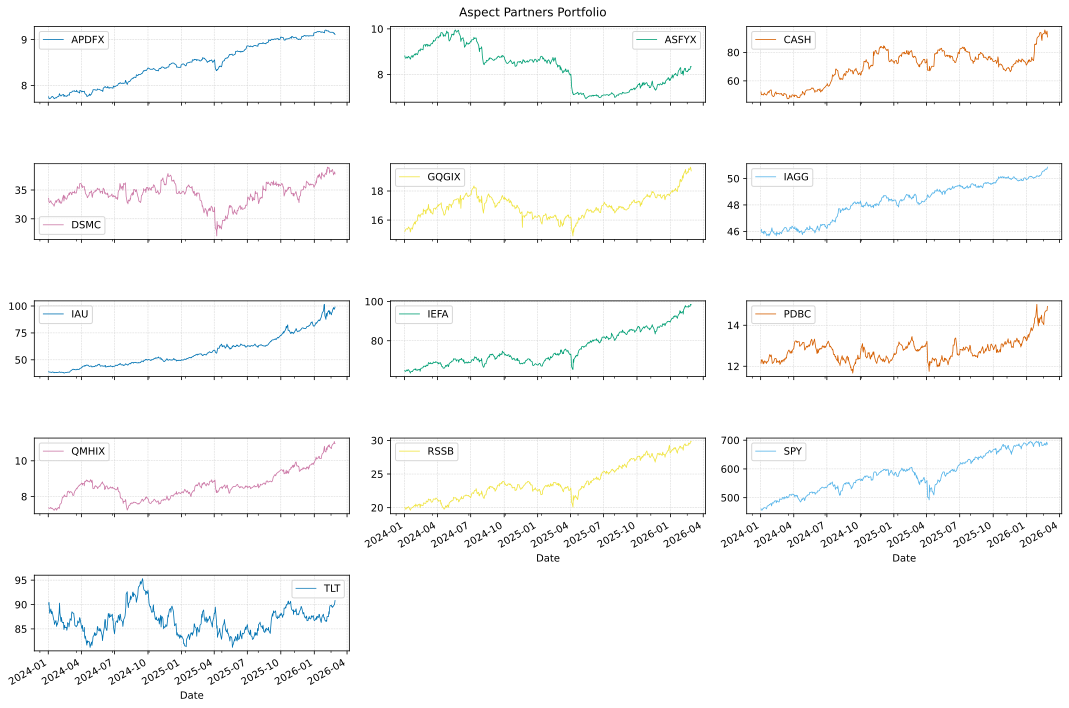

In [5]:
#data.plot(subplots = True, figsize = (15, 10));
axes = data1.plot(kind = 'line', figsize = (15, 10), subplots = True, grid = True,
          title = "Aspect Partners Portfolio", layout = (5, 3), sharex = True,
          sharey = False, legend = True, linewidth = 0.8);

# Customize grid for all subplots
for ax in axes.flatten():  # Flatten
    ax.grid(
        True,
        linestyle='--',   # Dashed lines
        linewidth=0.5,    # Thinner lines
        color='lightgray' # Pale color
    )

plt.tight_layout()
plt.show()


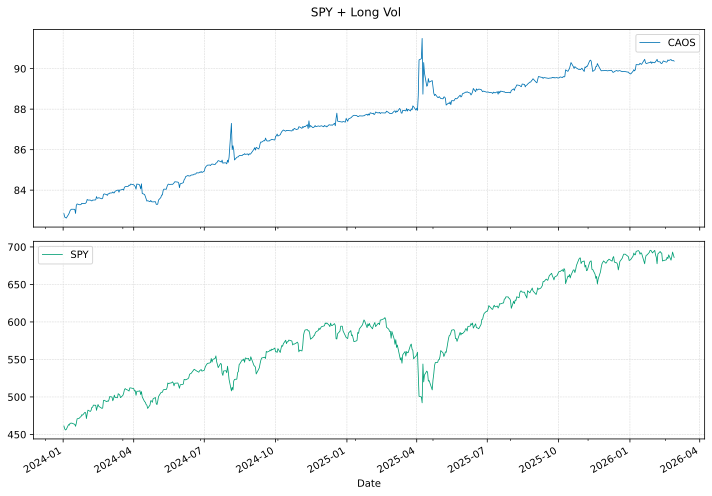

In [6]:
#data.plot(subplots = True, figsize = (15, 10));
axes = data2.plot(kind = 'line', figsize = (10, 7), subplots = True, grid = True,
          title = "SPY + Long Vol", layout = (2, 1), sharex = True,
          sharey = False, legend = True, linewidth = 0.8);

# Customize grid for all subplots
for ax in axes.flatten():  # Flatten
    ax.grid(
        True,
        linestyle='--',   # Dashed lines
        linewidth=0.5,    # Thinner lines
        color='lightgray' # Pale color
    )

plt.tight_layout()
plt.show()

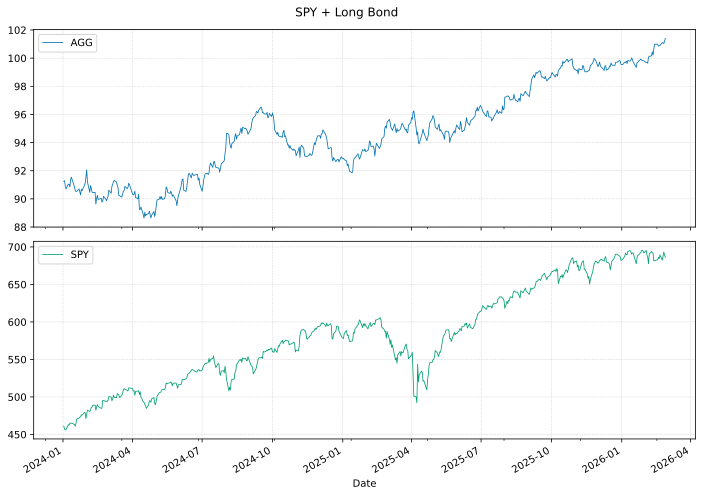

In [7]:
#data.plot(subplots = True, figsize = (15, 10));
axes = data3.plot(kind = 'line', figsize = (10, 7), subplots = True, grid = True,
          title = "SPY + Long Bond", layout = (2, 1), sharex = True,
          sharey = False, legend = True, linewidth = 0.8);

# Customize grid for all subplots
for ax in axes.flatten():  # Flatten
    ax.grid(
        True,
        linestyle='--',   # Dashed lines
        linewidth=0.5,    # Thinner lines
        color='lightgray' # Pale color
    )

plt.tight_layout()
plt.show()

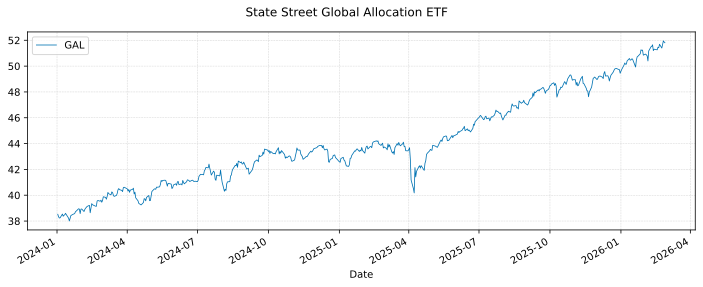

In [8]:
#data.plot(subplots = True, figsize = (15, 10));
axes = data4.plot(kind = 'line', figsize = (10, 7), subplots = True, grid = True,
          title = "State Street Global Allocation ETF", layout = (2, 1), sharex = True,
          sharey = False, legend = True, linewidth = 0.8);

# Customize grid for all subplots
for ax in axes.flatten():  # Flatten
    ax.grid(
        True,
        linestyle='--',   # Dashed lines
        linewidth=0.5,    # Thinner lines
        color='lightgray' # Pale color
    )

plt.tight_layout()
plt.show()

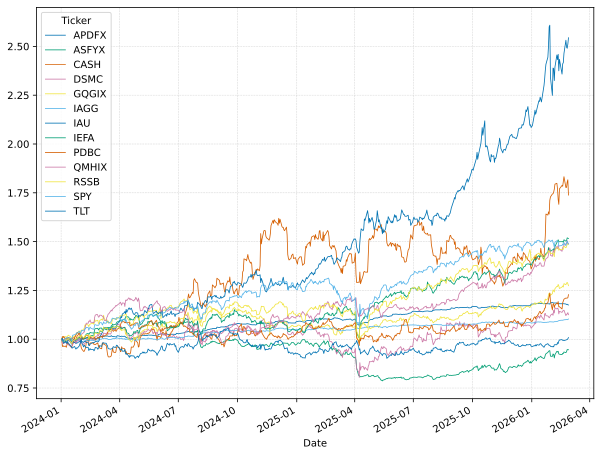

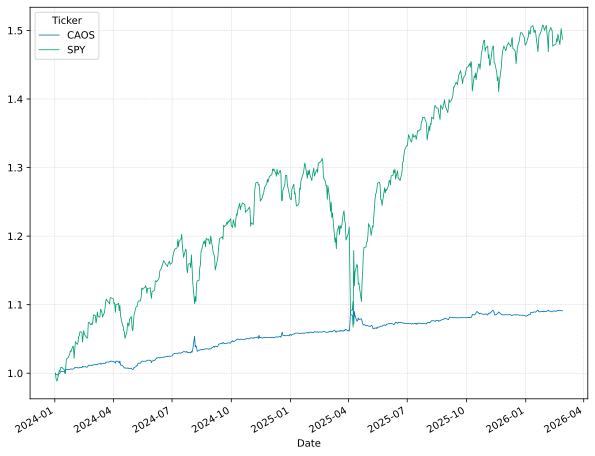

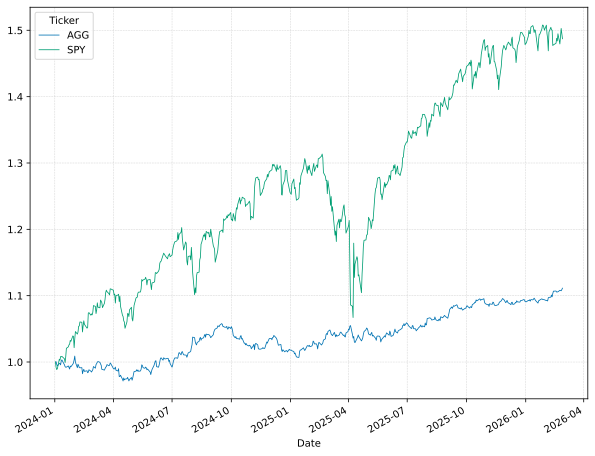

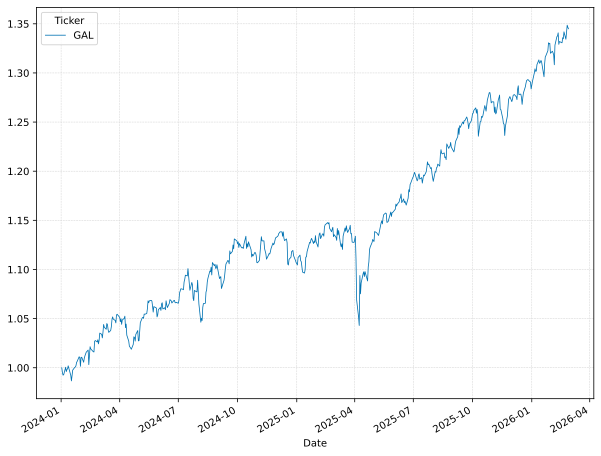

In [9]:
# Relative Volatility
data = [data1, data2, data3, data4]
for i in range(len(data)):
    ax = (data[i]/data[i].iloc[0]).plot(kind = 'line', figsize = (10, 8), 
                                           grid = True,
                                           legend = True, 
                                           linewidth = 0.8)
    ax.grid(
            True,
            linestyle='--',   # Dashed lines
            linewidth=0.5,    # Thinner lines
            color='lightgray') # Pale color

In [10]:
# Generate CSV file to perform the analysis
data1.to_csv('aspect_partners.csv')
data2.to_csv('SPY_Long_Vol.csv')
data3.to_csv('SPY_Long_Bond.csv')
data4.to_csv('State_Street_ETF.csv')
